<a href="https://colab.research.google.com/github/zzzer0-wav/myDTA_2026/blob/main/ML/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Щоб результати були однаковими щоразу (відтворюваність)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

print("Бібліотеки готові ✅")

Бібліотеки готові ✅


У реальній роботі завантажте CSV через `pd.read_csv("file.csv")`.

**Генеруємо дані**  
Створюємо таблицю з ознаками й «справжньою» ціною (з невеликим випадковим шумом, як у житті).

In [4]:
n = 1000  # скільки квартир

area      = np.random.normal(60, 20, n).clip(20, 140)        # площа, м²
rooms     = np.clip(np.round(area / 25 + np.random.normal(0, 0.6, n)), 1, 5)  # кімнати
floor     = np.random.randint(1, 25, n)                      # поверх
dist_km   = np.random.exponential(5, n).clip(0.3, 25)        # відстань до центру, км
age_years = np.random.randint(0, 60, n)                      # вік будинку, років

# "Справжня" логіка ціни (у тис. $) — у житті її НЕ знаємо, модель має її відкрити:
price = (
    40                       # базова
    + area * 1.8             # кожен м² додає
    + rooms * 5              # кожна кімната
    + floor * 0.4            # трохи за поверх
    - dist_km * 3.0          # далі від центру — дешевше
    - age_years * 0.5        # старіший будинок — дешевше
    + np.random.normal(0, 12, n)   # шум: усе інше, що ми не врахували
).clip(20, None)

df = pd.DataFrame({
    "area": area.round(1),
    "rooms": rooms.astype(int),
    "floor": floor,
    "dist_km": dist_km.round(1),
    "age_years": age_years,
    "price": price.round(1),
})



In [5]:
print(f'Розмір таблиці: {df.shape[0]} рядків х {df.shape[1]} стовпців')
print('\nЧи є пропуски?')
print(df.isna().sum().sum())
print(df.dtypes)
df.describe().round(2)

Розмір таблиці: 1000 рядків х 6 стовпців

Чи є пропуски?
0
area         float64
rooms          int64
floor          int64
dist_km      float64
age_years      int64
price        float64
dtype: object


,area,rooms,floor,dist_km,age_years,price
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,60.49,2.48,12.69,4.96,30.39,136.25
std,19.33,0.95,7.00,4.71,17.23,44.99
min,20.00,1.00,1.00,0.30,0.00,20.00
25%,47.08,2.00,6.00,1.50,16.00,104.15
50%,60.50,2.00,13.00,3.60,30.00,136.75
75%,73.00,3.00,19.00,7.00,45.25,165.45
max,137.10,5.00,24.00,25.00,59.00,282.40


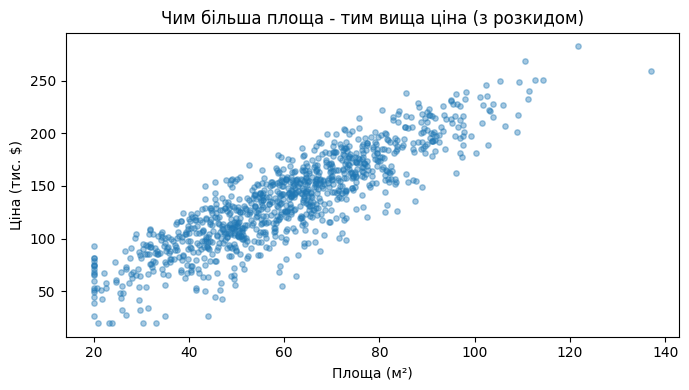

In [6]:
plt.figure(figsize=(7, 4))
plt.scatter(df['area'], df['price'], alpha=0.4, s=15)
plt.xlabel('Площа (м²)')
plt.ylabel('Ціна (тис. $)')
plt.title('Чим більша площа - тим вища ціна (з розкидом)')
plt.tight_layout()
plt.show()

In [7]:
from sklearn.model_selection import train_test_split

X = df[['area', 'rooms', 'floor', 'dist_km', 'age_years']] # features - ознаки
y = df['price'] # target - ціль

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print('Навчальна вибірка:', X_train.shape[0], 'квартир')
print('Тестова вибірка:', X_test.shape[0], 'квартир')

Навчальна вибірка: 800 квартир
Тестова вибірка: 200 квартир


### Лінійна регресія

In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

compare = pd.DataFrame({
    'real_price': y_test[:5].round(2),
    'predict_price': y_pred[:5].round(2)
})
compare['error'] = (compare['predict_price'] - compare['real_price']).round(2)

compare

,real_price,predict_price,error
521,119.1,129.69,10.59
737,173.3,178.26,4.96
740,20.0,26.36,6.36
660,93.7,110.87,17.17
411,100.6,97.21,-3.39


МАЕ - наскільки в середньому ми помилилися - 7 --> 7k$

RMSE - схожу на МАЕ, сильніше карає великі промахи - менще = краще

R² - яку частину розкиду модель може оцінити - [0,;1.0]
-> 1 - ідеально, 0 - вгадує середній показник

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print(f'МАЕ = {mae:.1f}k$ (у середьному помиляємося на стільки)')
print(f'MSE = {mse:.1f}')
print(f'RMSE =  {rmse:.1f}k$')
print(f'R² = {r2:.3f} (модель пояснює  {r2 * 100:.1f}% розкиду ціни)')

МАЕ = 8.7k$ (у середьному помиляємося на стільки)
MSE = 117.3
RMSE =  10.8k$
R² = 0.947 (модель пояснює  94.7% розкиду ціни)


In [21]:
coefs = pd.DataFrame({
    'features': X.columns,
    'coef': model.coef_.round(2)
}).sort_values('coef', key=abs, ascending=False)

print(f'Базова ціна: {model.intercept_:.2f}k$\n')
print(f'Як кожна ознака впливає на ціну')

coefs

Базова ціна: 40.83k$

Як кожна ознака впливає на ціну


,features,coef
1,rooms,5.22
3,dist_km,-3.07
0,area,1.78
4,age_years,-0.49
2,floor,0.39


In [24]:
price2 = (
    40.83
    + area = 1.78,
    + rooms * 5.22,
    + dist_km = * (-3.07),
    + age_years * (-0.49),
    + floor * (0.39)
)

SyntaxError: cannot assign to expression here. Maybe you meant '==' instead of '='? (164341708.py, line 2)